Required package 'emcee' not found. Auto-installing... Please wait.
Installation complete.

Loading S0-2 data from GitHub...

Executing MCMC for FULL R.O.M....
  Burn-in...
  Production...

Executing MCMC for ABLATED (no Z_sys, no Prec)...
  Burn-in...
  Production...

EMPIRICAL VALIDATION: MCMC POSTERIORS vs GRAVITY COLLABORATION REFERENCE
Reference values obtained from independent astrometric interferometry (GRAVITY).

[FULL R.O.M.]
  Kinematic Projection (β):
    Extracted: 0.006336 (+0.000887 / -0.000825)
    Reference: 0.006450  |  In 95% CI? [YES]
  Inclination (i):
    Extracted: 134.66° (+6.94° / -9.78°)
    Reference: 134.00°     |  In 95% CI? [YES]
  Background Drift (v_z0):
    Extracted: -20.05 km/s (+5.29 / -5.70)
    Reference: -20.00 km/s  |  In 95% CI? [YES]
  Degeneracy Diagnostics:
    corr(β, i):    +0.972  (Degeneracy ridge geometry)
    corr(β, v_z0): -0.865  (Z_sys active physical signature)

[ABLATED (Classical Keplerian)]
  Kinematic Projection (β):
    Extracte

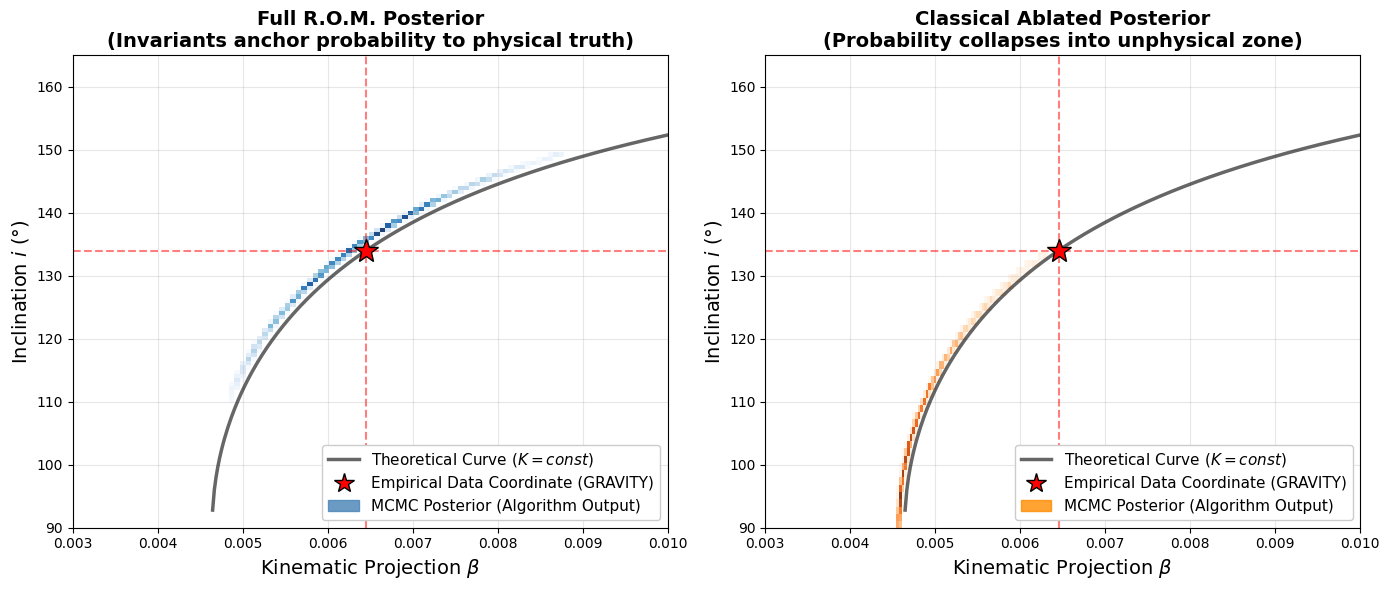

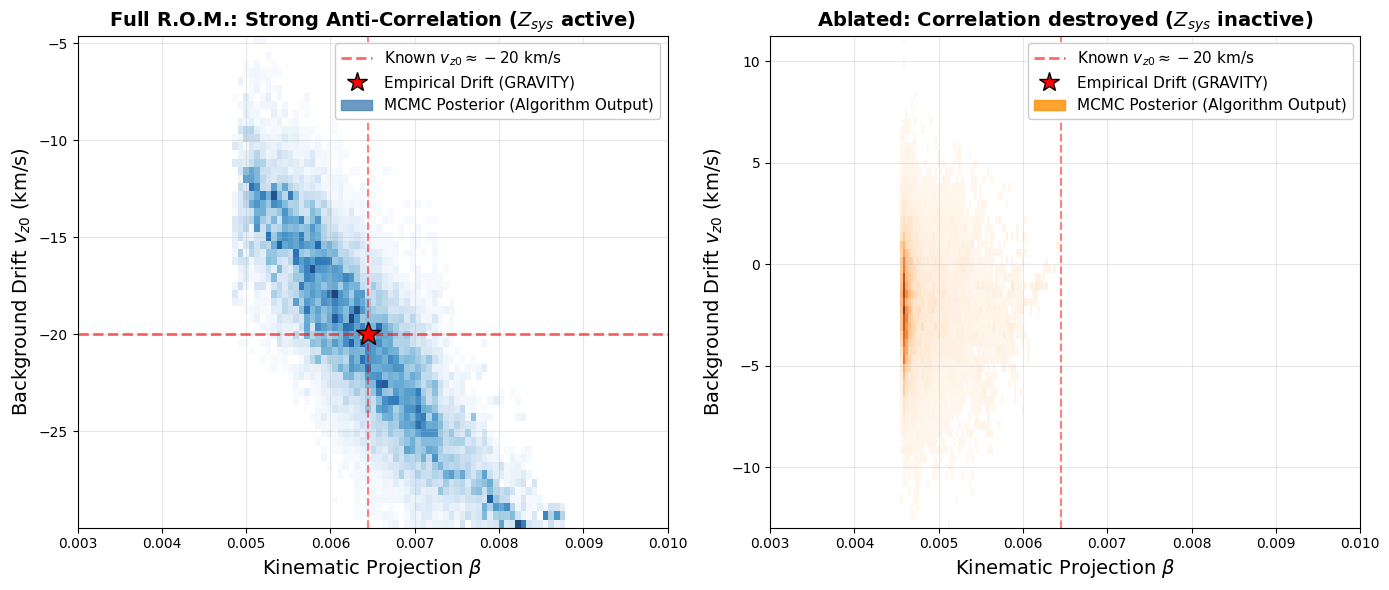

In [1]:
# ==========================================
# 0. AUTO-INSTALL DEPENDENCIES (FOOLPROOF)
# ==========================================
try:
    import emcee
except ImportError:
    print("Required package 'emcee' not found. Auto-installing... Please wait.")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "emcee", "-q"])
    import emcee
    print("Installation complete.\n")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import time
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. PARAMETERS & DATA IMPORT
# ==========================================
C_KMS = 299792.458
P_YRS = 16.0518
P_DAYS = P_YRS * 365.25
T_PERI = 58257.698

print("Loading S0-2 data from GitHub...")
url = "https://raw.githubusercontent.com/AntonRize/WILL/d24ab6ff6f4a29c93154ec2e678f6e9550a80b56/DATA/S0-2_DataS1_full.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()

t_obs = df['MJD'].values
vz_obs = df['RV_km_s'].values
sigma_vz = df['sigma_km_s'].values

Z_obs = 1.0 + (vz_obs / C_KMS)
sigma_Z = sigma_vz / C_KMS

# ==========================================
# 2. R.O.M. KINEMATIC ENGINE
# ==========================================
def get_phase(t, t_peri, P, e):
    M = (2 * np.pi / P) * (t - t_peri)
    E = M.copy()
    for _ in range(20):
        E = E - (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
    return 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2),
                           np.sqrt(1 - e) * np.cos(E / 2))

def generate_z_model(t_obs, o, beta, i_inc, beta_z0, e, omega_0, use_zsys=True, use_precession=True):
    if use_precession:
        delta_phi = (6 * np.pi * beta**2) / (1 - e**2)
        orbits = (t_obs - T_PERI) / P_DAYS
        omega_d = omega_0 + delta_phi * orbits
    else:
        omega_d = omega_0

    K = (beta / np.sqrt(1 - e**2)) * np.sin(i_inc)
    beta_los = K * (np.cos(o + omega_d) + e * np.cos(omega_d))

    if use_zsys:
        beta_o_sq = (beta**2) * (1 + e**2 + 2 * e * np.cos(o)) / (1 - e**2)
        kappa_o_sq = 2 * (beta**2) * (1 + e * np.cos(o)) / (1 - e**2)
        Z_sys = (1 - beta_o_sq)**(-0.5) * (1 - kappa_o_sq)**(-0.5)
    else:
        Z_sys = 1.0

    return Z_sys * (1 + beta_los) * (1 + beta_z0)

# ==========================================
# 3. MCMC LOGIC
# ==========================================
def make_log_prob(use_zsys, use_precession):
    def log_prior(params):
        beta, i, bz0, e, om = params
        if not (0.001 < beta < 0.05): return -np.inf
        if not (0.0 < i < np.pi): return -np.inf
        if not (-0.0001 < bz0 < 0.0001): return -np.inf
        if not (0.5 < e < 0.99): return -np.inf
        if not (0.0 < om < 2 * np.pi): return -np.inf
        return np.log(np.sin(i) + 1e-30)

    def log_likelihood(params):
        beta, i, bz0, e, om = params
        try:
            o = get_phase(t_obs, T_PERI, P_DAYS, e)
            Z_model = generate_z_model(t_obs, o, beta, i, bz0, e, om, use_zsys=use_zsys, use_precession=use_precession)
            if np.any(np.isnan(Z_model)) or np.any(np.isinf(Z_model)):
                return -np.inf
            chi2 = np.sum(((Z_obs - Z_model) / sigma_Z)**2)
            return -0.5 * chi2
        except:
            return -np.inf

    def log_prob(params):
        lp = log_prior(params)
        if not np.isfinite(lp): return -np.inf
        ll = log_likelihood(params)
        if not np.isfinite(ll): return -np.inf
        return lp + ll
    return log_prob

ndim = 5
nwalkers = 50
nsteps_burn = 1500
nsteps_prod = 3000

configs = [
    ("FULL R.O.M.", True, True, [0.006448, np.radians(135.68), -20.56/C_KMS, 0.88498, np.radians(66.26)]),
    ("ABLATED (no Z_sys, no Prec)", False, False, [0.004700, np.radians(103.35), -2.19/C_KMS, 0.88497, np.radians(64.42)]),
]

all_samples = {}

for model_name, use_zsys, use_prec, p0_center in configs:
    print(f"\nExecuting MCMC for {model_name}...")
    log_prob_fn = make_log_prob(use_zsys, use_prec)

    p0 = np.array(p0_center)
    scatter = np.array([0.0003, 0.03, 2.0/C_KMS, 0.002, 0.02])
    pos = p0 + scatter * np.random.randn(nwalkers, ndim)

    pos[:, 0] = np.clip(pos[:, 0], 0.002, 0.04)
    pos[:, 1] = np.clip(pos[:, 1], 0.05, np.pi - 0.05)
    pos[:, 2] = np.clip(pos[:, 2], -0.00009, 0.00009)
    pos[:, 3] = np.clip(pos[:, 3], 0.55, 0.98)
    pos[:, 4] = np.clip(pos[:, 4], 0.05, 2*np.pi - 0.05)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob_fn)

    print("  Burn-in...")
    state = sampler.run_mcmc(pos, nsteps_burn, progress=False)
    sampler.reset()

    print("  Production...")
    sampler.run_mcmc(state, nsteps_prod, progress=False)

    flat_samples = sampler.get_chain(flat=True)
    samples_hr = flat_samples.copy()
    samples_hr[:, 1] = np.degrees(flat_samples[:, 1])
    samples_hr[:, 2] = flat_samples[:, 2] * C_KMS
    all_samples[model_name] = samples_hr

s_full = all_samples["FULL R.O.M."]
s_abl = all_samples["ABLATED (no Z_sys, no Prec)"]

# ==========================================
# 4. EMPIRICAL VALIDATION & COMPARATIVE METRICS
# ==========================================
print(f"\n{'='*85}")
print("EMPIRICAL VALIDATION: MCMC POSTERIORS vs GRAVITY COLLABORATION REFERENCE")
print("Reference values obtained from independent astrometric interferometry (GRAVITY).")
print(f"{'='*85}")

GRAVITY_BETA = 0.00645
GRAVITY_I = 134.0
GRAVITY_VZ0 = -20.0

for name, s in [("FULL R.O.M.", s_full), ("ABLATED (Classical Keplerian)", s_abl)]:
    beta_s = s[:, 0]
    i_s = s[:, 1]
    vz_s = s[:, 2]

    corr_bi = np.corrcoef(beta_s, i_s)[0, 1]
    corr_bv = np.corrcoef(beta_s, vz_s)[0, 1]

    beta_q16, beta_q50, beta_q84 = np.percentile(beta_s, [16, 50, 84])
    i_q16, i_q50, i_q84 = np.percentile(i_s, [16, 50, 84])
    vz_q16, vz_q50, vz_q84 = np.percentile(vz_s, [16, 50, 84])

    # Check if 95% Confidence Interval (2.5 to 97.5 percentile) contains the GRAVITY truth
    beta_ci95 = (np.percentile(beta_s, 2.5) <= GRAVITY_BETA <= np.percentile(beta_s, 97.5))
    i_ci95 = (np.percentile(i_s, 2.5) <= GRAVITY_I <= np.percentile(i_s, 97.5))
    vz0_ci95 = (np.percentile(vz_s, 2.5) <= GRAVITY_VZ0 <= np.percentile(vz_s, 97.5))

    print(f"\n[{name}]")
    print(f"  Kinematic Projection (β):")
    print(f"    Extracted: {beta_q50:.6f} (+{beta_q84-beta_q50:.6f} / -{beta_q50-beta_q16:.6f})")
    print(f"    Reference: {GRAVITY_BETA:.6f}  |  In 95% CI? {'[YES]' if beta_ci95 else '[NO]'}")

    print(f"  Inclination (i):")
    print(f"    Extracted: {i_q50:.2f}° (+{i_q84-i_q50:.2f}° / -{i_q50-i_q16:.2f}°)")
    print(f"    Reference: {GRAVITY_I:.2f}°     |  In 95% CI? {'[YES]' if i_ci95 else '[NO]'}")

    print(f"  Background Drift (v_z0):")
    print(f"    Extracted: {vz_q50:.2f} km/s (+{vz_q84-vz_q50:.2f} / -{vz_q50-vz_q16:.2f})")
    print(f"    Reference: {GRAVITY_VZ0:.2f} km/s  |  In 95% CI? {'[YES]' if vz0_ci95 else '[NO]'}")

    print(f"  Degeneracy Diagnostics:")
    print(f"    corr(β, i):    {corr_bi:+.3f}  (Degeneracy ridge geometry)")
    print(f"    corr(β, v_z0): {corr_bv:+.3f}  (Z_sys active physical signature)")

# ==========================================
# 5. PUBLICATION GRADE PLOTTING
# ==========================================
print("\nGenerating publication plots...")

ridge_line = mlines.Line2D([], [], color='black', lw=2.5, ls='-', alpha=0.6, label='Theoretical Curve ($K=const$)')
truth_marker = mlines.Line2D([], [], color='red', marker='*', linestyle='None', markersize=15, markeredgecolor='black', label='Empirical Data Coordinate (GRAVITY)')
mcmc_patch_full = mpatches.Patch(color='steelblue', alpha=0.8, label='MCMC Posterior (Algorithm Output)')
mcmc_patch_abl = mpatches.Patch(color='darkorange', alpha=0.8, label='MCMC Posterior (Algorithm Output)')

K_ref = 0.00645 * np.sin(np.radians(134.0)) / np.sqrt(1 - 0.88466**2)
beta_curve = np.linspace(0.002, 0.012, 500)
sin_i_curve = K_ref * np.sqrt(1 - 0.88466**2) / beta_curve
valid = np.abs(sin_i_curve) <= 1
i_curve = 180.0 - np.degrees(np.arcsin(np.clip(sin_i_curve[valid], -1, 1)))

# --- PLOT 1: Beta vs Inclination ---
fig3, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
ax1.hist2d(s_full[:, 0], s_full[:, 1], bins=60, cmap='Blues', cmin=1, alpha=0.9)
ax1.plot(beta_curve[valid], i_curve, color='black', lw=2.5, ls='-', alpha=0.6)
ax1.axhline(134.0, color='red', ls='--', lw=1.5, alpha=0.5)
ax1.axvline(0.00645, color='red', ls='--', lw=1.5, alpha=0.5)
ax1.plot(0.00645, 134.0, marker='*', color='red', markersize=18, markeredgecolor='black')
ax1.set_xlabel(r'Kinematic Projection $\beta$', fontsize=14)
ax1.set_ylabel(r'Inclination $i$ (°)', fontsize=14)
ax1.set_title('Full R.O.M. Posterior\n(Invariants anchor probability to physical truth)', fontsize=14, fontweight='bold')
ax1.set_xlim(0.003, 0.010)
ax1.set_ylim(90, 165)
ax1.legend(handles=[ridge_line, truth_marker, mcmc_patch_full], loc='lower right', fontsize=11, framealpha=1.0)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.hist2d(s_abl[:, 0], s_abl[:, 1], bins=60, cmap='Oranges', cmin=1, alpha=0.9)
ax2.plot(beta_curve[valid], i_curve, color='black', lw=2.5, ls='-', alpha=0.6)
ax2.axhline(134.0, color='red', ls='--', lw=1.5, alpha=0.5)
ax2.axvline(0.00645, color='red', ls='--', lw=1.5, alpha=0.5)
ax2.plot(0.00645, 134.0, marker='*', color='red', markersize=18, markeredgecolor='black')
ax2.set_xlabel(r'Kinematic Projection $\beta$', fontsize=14)
ax2.set_ylabel(r'Inclination $i$ (°)', fontsize=14)
ax2.set_title('Classical Ablated Posterior\n(Probability collapses into unphysical zone)', fontsize=14, fontweight='bold')
ax2.set_xlim(0.003, 0.010)
ax2.set_ylim(90, 165)
ax2.legend(handles=[ridge_line, truth_marker, mcmc_patch_abl], loc='lower right', fontsize=11, framealpha=1.0)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig3.savefig('/content/beta_i_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# --- PLOT 2: Beta vs Background Drift ---
fig4, axes2 = plt.subplots(1, 2, figsize=(14, 6))
vz0_truth_marker = mlines.Line2D([], [], color='red', marker='*', linestyle='None', markersize=15, markeredgecolor='black', label='Empirical Drift (GRAVITY)')
vz0_line = mlines.Line2D([], [], color='red', lw=2, ls='--', alpha=0.6, label='Known $v_{z0} \\approx -20$ km/s')

ax1 = axes2[0]
ax1.hist2d(s_full[:, 0], s_full[:, 2], bins=60, cmap='Blues', cmin=1, alpha=0.9)
ax1.axhline(-20.0, color='red', ls='--', lw=2, alpha=0.6)
ax1.axvline(0.00645, color='red', ls='--', lw=1.5, alpha=0.5)
ax1.plot(0.00645, -20.0, marker='*', color='red', markersize=18, markeredgecolor='black')
ax1.set_xlabel(r'Kinematic Projection $\beta$', fontsize=14)
ax1.set_ylabel(r'Background Drift $v_{z0}$ (km/s)', fontsize=14)
ax1.set_title('Full R.O.M.: Strong Anti-Correlation ($Z_{sys}$ active)', fontsize=14, fontweight='bold')
ax1.set_xlim(0.003, 0.010)
ax1.legend(handles=[vz0_line, vz0_truth_marker, mcmc_patch_full], loc='upper right', fontsize=11, framealpha=1.0)
ax1.grid(True, alpha=0.3)

ax2 = axes2[1]
ax2.hist2d(s_abl[:, 0], s_abl[:, 2], bins=60, cmap='Oranges', cmin=1, alpha=0.9)
ax2.axhline(-20.0, color='red', ls='--', lw=2, alpha=0.6)
ax2.axvline(0.00645, color='red', ls='--', lw=1.5, alpha=0.5)
ax2.plot(0.00645, -20.0, marker='*', color='red', markersize=18, markeredgecolor='black')
ax2.set_xlabel(r'Kinematic Projection $\beta$', fontsize=14)
ax2.set_ylabel(r'Background Drift $v_{z0}$ (km/s)', fontsize=14)
ax2.set_title('Ablated: Correlation destroyed ($Z_{sys}$ inactive)', fontsize=14, fontweight='bold')
ax2.set_xlim(0.003, 0.010)
ax2.legend(handles=[vz0_line, vz0_truth_marker, mcmc_patch_abl], loc='upper right', fontsize=11, framealpha=1.0)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig4.savefig('/content/beta_vz0_comparison.png', dpi=300, bbox_inches='tight')
plt.show()